In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.font_manager as fm
import seaborn as sb
import skimage

# Other Crops of first two rows of Figure4

In [3]:
datasets_colors = {'BBBC039':'#80ED99',
                   'mnfinder_train':'#00F0B5',
                   'mnDINO_data_01':'#192A56',
                   'mnDINO_data_02':'#00A3FF'}

plt.rcParams.update({'font.size':12})

In [4]:
IMG_PATH = '/scr/yren/annotated_mn_datasets/'
meta = pd.read_csv(os.path.join(IMG_PATH, 'metadata.csv'))
meta.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.5,validation,HeLa
2,C1-20X_c0_B3_Tile-15.tif,mnDINO_data_02,20,6.5,test,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,mnDINO_data_02,20,6.5,validation,RPE1


In [4]:
meta[(meta.datasets == 'BBBC039') & (meta.split == 'train')]

,filenames,datasets,magnification,micron,split,cell_line
77,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,BBBC039,20,13.1,train,U2OS
79,IXMtest_H07_s2_w1D8F30687-16A2-4A0D-BDD5-37725...,BBBC039,20,13.1,train,U2OS
80,IXMtest_G16_s3_w1B4690283-D75E-4DFB-92B0-29419...,BBBC039,20,13.1,train,U2OS
81,IXMtest_F12_s9_w1CD127D58-4641-41D3-88CC-E12B7...,BBBC039,20,13.1,train,U2OS
83,IXMtest_G16_s6_w1C3F175E2-0AF5-401C-AC5C-8E128...,BBBC039,20,13.1,train,U2OS
...,...,...,...,...,...,...
220,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,BBBC039,20,13.1,train,U2OS
224,IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2...,BBBC039,20,13.1,train,U2OS
226,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,20,13.1,train,U2OS
227,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,20,13.1,train,U2OS


In [5]:
meta[(meta.datasets == 'mnDINO_data_02') & (meta.split == 'train')]

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1


In [6]:
bbbc039_imid = 'IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B61FF39F7.tif'
mnfinder_imid = '2022-10-14_U2OS-7.tif'
mndino_01_imid = 'C2-20X_c0-DAPI-GFP_B3_Tile-10.tif'
mndino_02_imid = 'C1-20X_c0_phalloidin_C3_Tile-18.tif'

bbbc039_im = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'images', bbbc039_imid))
bbbc039_nuc = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'nuclei_masks', bbbc039_imid))
bbbc039_gt = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'mn_masks', bbbc039_imid.replace('.tif', '.png')))

mnfinder_im = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'images', mnfinder_imid))
mnfinder_nuc = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'nuclei_masks', mnfinder_imid))
mnfinder_gt = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'mn_masks', mnfinder_imid.replace('.tif', '.png')))

mndino_01_im = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'images', mndino_01_imid))
mndino_01_nuc = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'nuclei_masks', mndino_01_imid))
mndino_01_gt = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'mn_masks', mndino_01_imid.replace('.tif', '.png')))

mndino_02_im = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'images', mndino_02_imid))
mndino_02_nuc = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'nuclei_masks', mndino_02_imid))
mndino_02_gt = skimage.io.imread(os.path.join(IMG_PATH, 'train', 'mn_masks', mndino_02_imid.replace('.tif', '.png')))

In [7]:
imgs = [bbbc039_im, mnfinder_im, mndino_01_im, mndino_02_im]
nucs = [bbbc039_nuc, mnfinder_nuc, mndino_01_nuc, mndino_02_nuc]
gts = [bbbc039_gt, mnfinder_gt, mndino_01_gt, mndino_02_gt]

# nucs_new = []
gts_new = []

# Change nuclei mask to gray, micronuclei mask to violet
# Concatenate micronuclei
for i in range(4):
    H, W = nucs[i].shape
    
    im = np.zeros((H, W, 3), dtype=np.uint8)
    
    
    nuclei_mask = (nucs[i] > 0)
    im[nuclei_mask] = [128, 128, 128] # gray mask
    
    gt_mask = (gts[i] > 0)
    im[gt_mask] = [238, 130, 238] # color: violet
    
    gts_new.append(im)

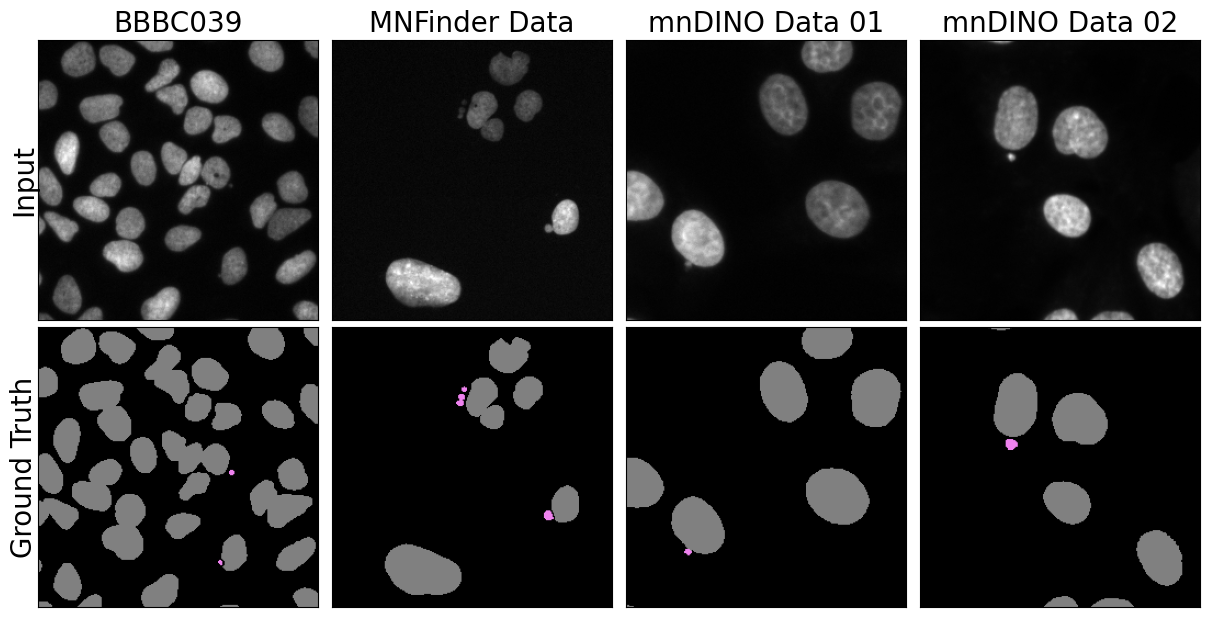

In [26]:
fig, ax = plt.subplots(2, 4, figsize=(15, 15))
fontprops = fm.FontProperties(size=8)
plt.subplots_adjust(wspace=0.05, hspace=-0.67)

col_labels = ['BBBC039', 'MNFinder Data', 'mnDINO Data 01',  'mnDINO Data 02']

PS = 256
for i in range(4):
    # first row
    if i==0: # BBBC039
        r,c = 130,210
    elif i == 1: # MNFinder
        r,c = 240,240
    elif i == 2: # Pilot Screen
        r,c = 2000,2050
    elif i == 3: # HeLa RPE1
        r,c = 1150,1500
    ax[0, i].imshow(imgs[i][r:r+PS,c:c+PS], cmap='gray')
    ax[1, i].imshow(gts_new[i][r:r+PS,c:c+PS,:])
    
    # set title
    ax[0, i].set_title(col_labels[i], fontsize=20)
    ax[0, 0].set_ylabel('Input', fontsize=20, rotation=90, va='center', labelpad=10)
    ax[1, 0].set_ylabel('Ground Truth', fontsize=20, rotation=90, va='center', labelpad=10)
    
    ax[0, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax[1, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)